# Single-Mask DF-DPC — Calculadora de parámetros de laboratorio

Implementa las condiciones geométricas descritas en el paper (Sección EXPERIMENT) y devuelve los rangos permitidos para:

- Distancia fuente–máscara $d_{sm}$
- Distancia máscara–detector $d_{md}$
- Distancia fuente–detector total $L = d_{sm}+d_{md}$ (con tope de laboratorio, por defecto **0.7 m**)
- Distancia muestra–detector $d_{od}$ (muestra apoyada contra la máscara)
- Magnificación geométrica $M$
- Ancho de slit $w$ — variable libre porque tu sistema lo modula con dos máscaras superpuestas
- Pasos de *dithering* (sub-período de máscara)
- Resolución limitada por foco y *pixel size* efectivo a la muestra

### Condiciones del paper
El alineamiento exige que la proyección de la máscara sobre el detector tenga un período entero $N$ veces el pitch del detector:
$$ p_m \cdot M \;=\; N \cdot p_d $$
donde
- $N=2$ → configuración **DPC** o **DF** (M ≈ 2×)

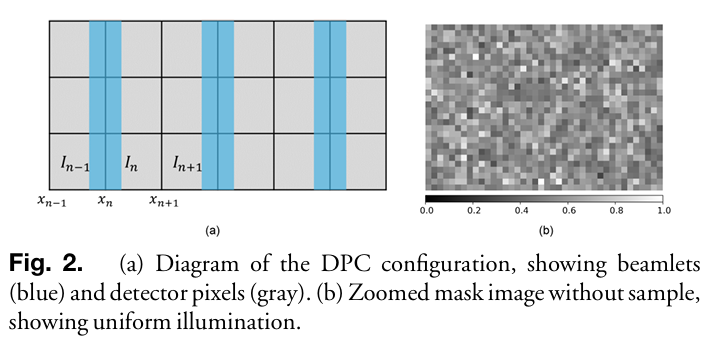


- $N=3$ → configuración **DF-DPC** (M ≈ 3×)

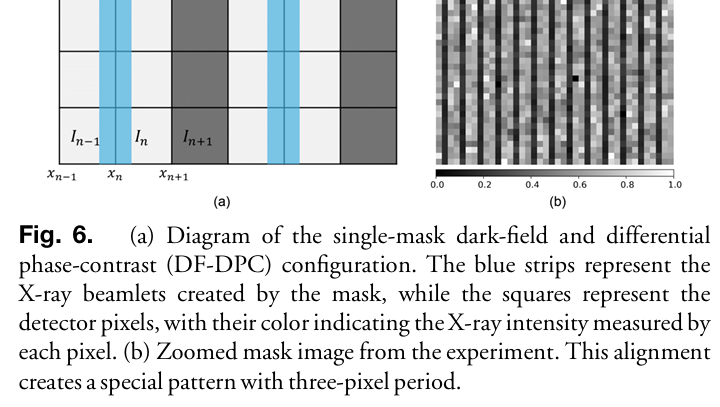

y la magnificación es $M = (d_{sm}+d_{md})/d_{sm}$, lo que fija el cociente entre distancias una vez elegida $N$.

In [33]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Parámetros de laboratorio

Los defaults coinciden con los del paper. `slit_um=None` deja que la calculadora elija el óptimo; asigná un número para forzar tu valor.

In [34]:
@dataclass
class LabSetup:
    # --- Máscara ---
    p_mask_um: float = 200.0       # período de la máscara [µm]
    slit_um: Optional[float] = None  # ancho de slit (None → se computa el óptimo)
    au_thickness_um: float = 50. # espesor del oro [µm]
    # Bounds del slit ajustable por superposición de dos máscaras:
    slit_min_um: float = 2.0      # mínimo alcanzable (fabricación / mecánica) [µm]
    slit_max_um: float = 100.0     # máximo alcanzable (< p_mask) [µm]
    slit_safety: float = 0.85     # factor de seguridad sobre el máximo teórico (0<f≤1)

    # --- Detector ---
    p_det_um: float = 50.0        # pixel pitch [µm]
    det_w_mm: float = 200.0        # ancho activo [mm]
    det_h_mm: float = 200.0        # alto activo  [mm]

    # --- Fuente ---
    focal_spot_um: float = 20.0   # diámetro nominal del foco [µm] (Hamamatsu: 7/20/50)
    kV: float = 17.0              # tensión del tubo [kV]

    # --- Restricciones del banco ---
    L_max_m: float = 1.00         # distancia fuente-detector máxima [m]
    L_min_m: float = 0.10         # distancia fuente-detector mínima razonable [m]

    # --- Adquisición ---
    config: str = 'DF-DPC'        # 'DPC', 'DF' o 'DF-DPC'
    n_dither: int = 16            # pasos de dithering por período de máscara

lab = LabSetup()
lab

LabSetup(p_mask_um=200.0, slit_um=None, au_thickness_um=50.0, slit_min_um=2.0, slit_max_um=100.0, slit_safety=0.85, p_det_um=50.0, det_w_mm=200.0, det_h_mm=200.0, focal_spot_um=20.0, kV=17.0, L_max_m=1.0, L_min_m=0.1, config='DF-DPC', n_dither=16)

## 2. Geometría según la configuración

Dada $N$ ($=2$ para DPC/DF, $=3$ para DF-DPC) y los pitches, queda fijada la magnificación nominal
$$M^\star = \frac{N\,p_d}{p_m}$$
y, para cualquier $L \le L_{max}$:
$$d_{sm} = \frac{L}{M^\star}, \qquad d_{md} = L\,\frac{M^\star-1}{M^\star}.$$

In [35]:
_N_BY_CONFIG = {'DPC': 2, 'DF': 2, 'DF-DPC': 3}

def nominal_magnification(lab: LabSetup, config: Optional[str] = None) -> float:
    cfg = (config or lab.config).upper()
    if cfg not in _N_BY_CONFIG:
        raise ValueError(f"config debe ser uno de {list(_N_BY_CONFIG)}")
    return _N_BY_CONFIG[cfg] * lab.p_det_um / lab.p_mask_um

def distances_from_L(L_m, M):
    d_sm = L_m / M
    return d_sm, L_m - d_sm

for cfg in ['DPC', 'DF-DPC']:
    M = nominal_magnification(lab, cfg)
    print(f"{cfg:7s}  N={_N_BY_CONFIG[cfg]}   M* = N·p_d/p_m = {M:.4f}")
    print(f"          p_mask·M* = {lab.p_mask_um*M:.2f} µm  vs  N·p_det = {_N_BY_CONFIG[cfg]*lab.p_det_um:.2f} µm")

DPC      N=2   M* = N·p_d/p_m = 0.5000
          p_mask·M* = 100.00 µm  vs  N·p_det = 100.00 µm
DF-DPC   N=3   M* = N·p_d/p_m = 0.7500
          p_mask·M* = 150.00 µm  vs  N·p_det = 150.00 µm


## 3. Optimización del ancho de slit

El slit $w$ es libre (sistema de doble máscara). Para que cada beamlet ilumine **un sólo pixel** del detector (contraste pixel-a-pixel — requisito de DPC y DF):

$$ \underbrace{w \cdot M}_{\text{geométrico}} \;+\; \underbrace{f_s\,(M-1)}_{\text{penumbra del foco}} \;\le\; p_d \;\;\Longrightarrow\;\; w_{\max} = \frac{p_d - f_s(M-1)}{M} $$

- **Si $f_s(M-1) \ge p_d$** la penumbra ya cubre un pixel: ningún slit funciona.
- **Óptimo recomendado**: $w^\star = \text{safety} \cdot w_{\max}$, recortado a `[slit_min_um, slit_max_um]` y al duty < 0.9.
- Se chequea además que el paso de dithering ≤ $w^\star$ para muestrear el slit.

In [36]:
def slit_bounds(lab: LabSetup, config: Optional[str] = None):
    """Devuelve (w_max_teorico, w_opt, warnings_list) en µm."""
    cfg = (config or lab.config).upper()
    M = nominal_magnification(lab, cfg)
    fs, pd, pm = lab.focal_spot_um, lab.p_det_um, lab.p_mask_um
    warns = []
    penumbra_det = fs * (M - 1)
    if penumbra_det >= pd:
        warns.append(
            f"[CRÍTICO] Foco {fs:.1f} µm: penumbra en detector = {penumbra_det:.1f} µm ≥ p_det={pd:.1f} µm "
            f"para {cfg} (M={M:.3f}). No existe slit válido — usá un foco menor "
            f"(< {pd/(M-1):.1f} µm) o cambiá a una configuración con menor M."
        )
        return float('nan'), float('nan'), warns
    w_max_teo = (pd - penumbra_det) / M
    w_opt = lab.slit_safety * w_max_teo
    upper_mech = min(lab.slit_max_um, pm * 0.9)
    if w_opt > upper_mech:
        warns.append(f"[INFO] w_opt teórico ({w_opt:.1f} µm) excede límite mecánico/duty ({upper_mech:.1f} µm); recortado.")
        w_opt = upper_mech
    if w_opt < lab.slit_min_um:
        warns.append(
            f"[ADVERTENCIA] w_opt = {w_opt:.1f} µm < slit_min = {lab.slit_min_um:.1f} µm: "
            f"la doble máscara no puede abrir un slit tan angosto. Señal baja y/o contraste pobre."
        )
        w_opt = lab.slit_min_um
    if w_opt >= pm:
        warns.append(f"[CRÍTICO] w_opt {w_opt:.1f} µm ≥ p_mask {pm:.1f} µm: la máscara queda transparente.")
    step = pm / lab.n_dither
    if step > w_opt:
        warns.append(
            f"[ADVERTENCIA] paso de dithering ({step:.2f} µm) > w_opt ({w_opt:.2f} µm): "
            f"subí n_dither (actual {lab.n_dither}) a ≥ {int(np.ceil(pm/w_opt))}."
        )
    return w_max_teo, w_opt, warns

def resolve_slit(lab: LabSetup, config: Optional[str] = None):
    """Devuelve (w_um, source∈{'user','auto'}, warnings)."""
    _, w_opt, warns = slit_bounds(lab, config)
    if lab.slit_um is not None:
        return lab.slit_um, 'user', warns
    return w_opt, 'auto', warns

def ideal_slit_report(lab: LabSetup):
    print(f"Foco fuente : {lab.focal_spot_um:.1f} µm")
    print(f"p_mask      : {lab.p_mask_um:.1f} µm   p_det : {lab.p_det_um:.1f} µm")
    print(f"slit bounds : [{lab.slit_min_um:.1f}, {lab.slit_max_um:.1f}] µm   safety={lab.slit_safety}")
    print()
    for cfg in ['DPC', 'DF-DPC']:
        M = nominal_magnification(lab, cfg)
        w_max, w_opt, warns = slit_bounds(lab, cfg)
        print(f"--- {cfg}  (M={M:.3f}) ---")
        if np.isnan(w_max):
            print(f"  w_max (teórico) : N/A")
            print(f"  w_opt           : N/A")
        else:
            print(f"  w_max (teórico) : {w_max:6.2f} µm   (beamlet = 1 px)")
            print(f"  w_opt recomend. : {w_opt:6.2f} µm   (× safety {lab.slit_safety})")
            print(f"  zona iluminada en detector: {w_opt*M + lab.focal_spot_um*(M-1):5.2f} µm "
                  f"(geom {w_opt*M:.2f} + penumbra {lab.focal_spot_um*(M-1):.2f})")
            print(f"  duty cycle (w/p_mask) : {w_opt/lab.p_mask_um:.3f}")
        for w in warns:
            warnings.warn(w)
            print(f"  {w}")
        print()

ideal_slit_report(lab)

Foco fuente : 20.0 µm
p_mask      : 200.0 µm   p_det : 50.0 µm
slit bounds : [2.0, 100.0] µm   safety=0.85

--- DPC  (M=0.500) ---
  w_max (teórico) : 120.00 µm   (beamlet = 1 px)
  w_opt recomend. : 100.00 µm   (× safety 0.85)
  zona iluminada en detector: 40.00 µm (geom 50.00 + penumbra -10.00)
  duty cycle (w/p_mask) : 0.500
  [INFO] w_opt teórico (102.0 µm) excede límite mecánico/duty (100.0 µm); recortado.

--- DF-DPC  (M=0.750) ---
  w_max (teórico) :  73.33 µm   (beamlet = 1 px)
  w_opt recomend. :  62.33 µm   (× safety 0.85)
  zona iluminada en detector: 41.75 µm (geom 46.75 + penumbra -5.00)
  duty cycle (w/p_mask) : 0.312



C:\Users\Petya_\AppData\Local\Temp\ipykernel_2072\1001748415.py:63: UserWarning: [INFO] w_opt teórico (102.0 µm) excede límite mecánico/duty (100.0 µm); recortado.
  warnings.warn(w)


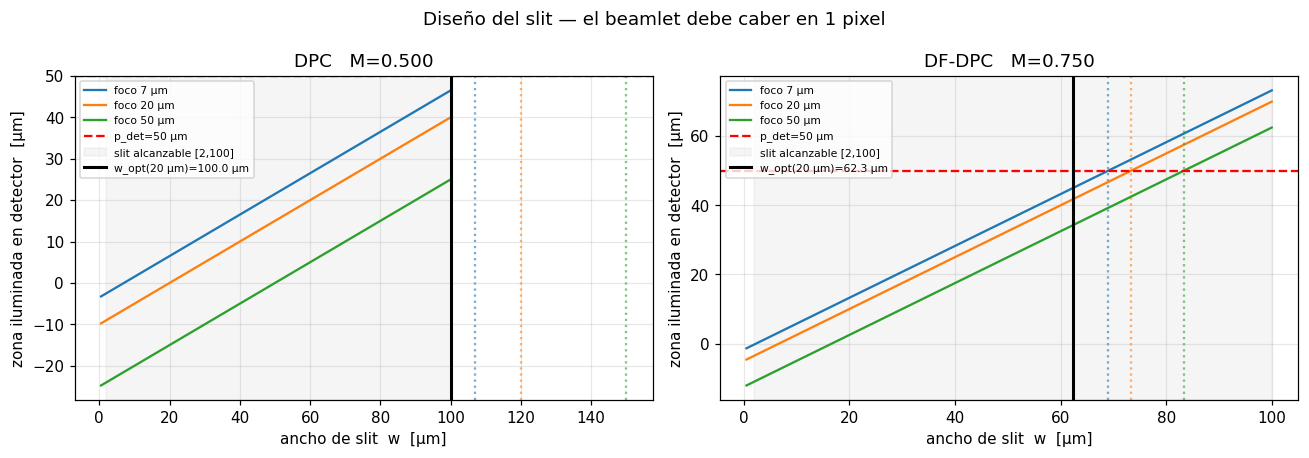

In [37]:
def plot_slit_design(lab: LabSetup):
    """Zona iluminada en detector vs ancho de slit, para los 3 focos del Hamamatsu."""
    focales = [7.0, 20.0, 50.0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, cfg in zip(axes, ['DPC', 'DF-DPC']):
        M = nominal_magnification(lab, cfg)
        w_range = np.linspace(0.5, min(lab.slit_max_um, lab.p_mask_um*0.95), 200)
        for fs in focales:
            zone = w_range * M + fs * (M - 1)
            line, = ax.plot(w_range, zone, label=f'foco {fs:.0f} µm')
            if fs * (M-1) < lab.p_det_um:
                w_max = (lab.p_det_um - fs*(M-1)) / M
                ax.axvline(w_max, color=line.get_color(), ls=':', alpha=0.6)
        ax.axhline(lab.p_det_um, color='red', ls='--', label=f'p_det={lab.p_det_um:.0f} µm')
        ax.axvspan(lab.slit_min_um, lab.slit_max_um, color='gray', alpha=0.08,
                   label=f'slit alcanzable [{lab.slit_min_um:.0f},{lab.slit_max_um:.0f}]')
        _, w_opt, _ = slit_bounds(lab, cfg)
        if not np.isnan(w_opt):
            ax.axvline(w_opt, color='black', lw=2, label=f'w_opt({lab.focal_spot_um:.0f} µm)={w_opt:.1f} µm')
        ax.set_xlabel('ancho de slit  w  [µm]')
        ax.set_ylabel('zona iluminada en detector  [µm]')
        ax.set_title(f"{cfg}   M={M:.3f}")
        ax.grid(alpha=.3); ax.legend(fontsize=7, loc='upper left')
    fig.suptitle('Diseño del slit — el beamlet debe caber en 1 pixel')
    fig.tight_layout()
    return fig

plot_slit_design(lab);

## 4. Rangos permitidos de distancias

Barrido de $L$ entre $L_{min}$ y $L_{max}$, manteniendo $p_m M = N p_d$.

In [38]:
def sweep_geometry(lab: LabSetup, config: Optional[str] = None, n: int = 200):
    M = nominal_magnification(lab, config)
    L = np.linspace(lab.L_min_m, lab.L_max_m, n)
    d_sm, d_md = distances_from_L(L, M)
    d_od = d_md  # muestra contra la máscara
    M_obj = (d_sm + d_od) / d_sm
    px_eff_um = lab.p_det_um / M_obj
    blur_det_um = lab.focal_spot_um * d_od / d_sm
    blur_obj_um = blur_det_um / M_obj
    return dict(L=L, d_sm=d_sm, d_md=d_md, d_od=d_od, M=np.full_like(L, M),
                M_obj=M_obj, px_eff_um=px_eff_um,
                blur_det_um=blur_det_um, blur_obj_um=blur_obj_um,
                fov_w_mm=lab.det_w_mm/M_obj, fov_h_mm=lab.det_h_mm/M_obj)

def summary_table(lab: LabSetup):
    rows = []
    for cfg in ['DPC', 'DF-DPC']:
        s = sweep_geometry(lab, cfg, n=2)
        _, w_opt, _ = slit_bounds(lab, cfg)
        w_show = lab.slit_um if lab.slit_um is not None else w_opt
        for i, tag in enumerate(['min', 'max']):
            rows.append([
                cfg, tag,
                f"{s['L'][i]*100:.1f}", f"{s['d_sm'][i]*100:.1f}",
                f"{s['d_md'][i]*100:.1f}", f"{s['M'][i]:.3f}",
                f"{s['px_eff_um'][i]:.2f}", f"{s['blur_obj_um'][i]:.2f}",
                f"{s['fov_w_mm'][i]:.1f} × {s['fov_h_mm'][i]:.1f}",
                f"{w_show:.2f}" if not np.isnan(w_show) else 'N/A',
            ])
    hdr = ['cfg','L', 'L[cm]', 'd_sm[cm]', 'd_md[cm]', 'M', 'px_eff[µm]', 'blur_obj[µm]', 'FOV[mm]', 'slit[µm]']
    width = [max(len(h), max(len(r[i]) for r in rows)) for i, h in enumerate(hdr)]
    line = '  '.join(h.ljust(width[i]) for i, h in enumerate(hdr))
    print(line); print('-'*len(line))
    for r in rows:
        print('  '.join(str(c).ljust(width[i]) for i,c in enumerate(r)))

summary_table(lab)

cfg     L    L[cm]  d_sm[cm]  d_md[cm]  M      px_eff[µm]  blur_obj[µm]  FOV[mm]        slit[µm]
------------------------------------------------------------------------------------------------
DPC     min  10.0   20.0      -10.0     0.500  100.00      -20.00        400.0 × 400.0  100.00  
DPC     max  100.0  200.0     -100.0    0.500  100.00      -20.00        400.0 × 400.0  100.00  
DF-DPC  min  10.0   13.3      -3.3      0.750  66.67       -6.67         266.7 × 266.7  62.33   
DF-DPC  max  100.0  133.3     -33.3     0.750  66.67       -6.67         266.7 × 266.7  62.33   


## 5. Punto de operación

Dada $L$ (m), devuelve todos los parámetros y emite warnings si la configuración no es físicamente realizable.

In [39]:
def operating_point(lab: LabSetup, L_m: float, config: Optional[str] = None):
    cfg = (config or lab.config).upper()
    if L_m > lab.L_max_m + 1e-9:
        raise ValueError(f"L={L_m*100:.1f} cm excede el tope ({lab.L_max_m*100:.1f} cm)")
    if L_m < lab.L_min_m:
        raise ValueError(f"L={L_m*100:.1f} cm por debajo del mínimo ({lab.L_min_m*100:.1f} cm)")
    M = nominal_magnification(lab, cfg)
    d_sm, d_md = distances_from_L(L_m, M)
    d_od = d_md
    M_obj = (d_sm + d_od) / d_sm
    px_eff_um = lab.p_det_um / M_obj
    blur_det_um = lab.focal_spot_um * d_od / d_sm
    blur_obj_um = blur_det_um / M_obj
    w_um, w_src, w_warns = resolve_slit(lab, cfg)
    illum_det_um = (w_um * M + blur_det_um) if (w_um and not np.isnan(w_um)) else float('nan')
    step_mask_um = lab.p_mask_um / lab.n_dither
    step_det_um  = step_mask_um * M
    print(f"Configuración: {cfg}   (N = {_N_BY_CONFIG[cfg]})")
    print(f"  L (fuente-detector)  : {L_m*100:6.2f} cm   [tope: {lab.L_max_m*100:.1f} cm]")
    print(f"  d_sm (fuente-máscara): {d_sm*100:6.2f} cm")
    print(f"  d_md (máscara-det.)  : {d_md*100:6.2f} cm")
    print(f"  d_od (muestra-det.)  : {d_od*100:6.2f} cm   (muestra contra máscara)")
    print(f"  Magnificación M      : {M:.4f}")
    print(f"  Período proyectado   : {lab.p_mask_um*M:6.2f} µm  ({_N_BY_CONFIG[cfg]} × p_det = {_N_BY_CONFIG[cfg]*lab.p_det_um:.2f} µm)")
    print()
    print(f"  Slit ({w_src})        : {w_um:6.2f} µm   (duty={w_um/lab.p_mask_um:.3f})" if not np.isnan(w_um) else "  Slit                : N/A")
    if not np.isnan(illum_det_um):
        print(f"  Zona iluminada en det.: {illum_det_um:6.2f} µm   (vs p_det={lab.p_det_um:.1f} µm)")
        if illum_det_um > lab.p_det_um:
            msg = f"beamlet ({illum_det_um:.2f} µm) excede p_det ({lab.p_det_um:.1f} µm) — pérdida de contraste pixel-a-pixel"
            warnings.warn(msg)
            print(f"  ⚠  {msg}")
    print()
    print(f"  Pixel efectivo en muestra : {px_eff_um:6.2f} µm/px")
    print(f"  Penumbra (foco {lab.focal_spot_um:.0f} µm):")
    print(f"       en detector  : {blur_det_um:6.2f} µm")
    print(f"       en muestra   : {blur_obj_um:6.2f} µm")
    print(f"  FOV en muestra   : {lab.det_w_mm/M_obj:5.1f} × {lab.det_h_mm/M_obj:5.1f} mm")
    print()
    print(f"  Dithering ({lab.n_dither} pasos / período):")
    print(f"       paso en máscara/muestra : {step_mask_um:6.2f} µm")
    print(f"       paso equivalente en det.: {step_det_um:6.2f} µm")
    for w in w_warns:
        warnings.warn(w)
        print(f"  {w}")
    return dict(cfg=cfg, M=M, d_sm=d_sm, d_md=d_md, d_od=d_od,
                slit_um=w_um, slit_source=w_src, illum_det_um=illum_det_um,
                px_eff_um=px_eff_um, blur_obj_um=blur_obj_um,
                step_mask_um=step_mask_um, step_det_um=step_det_um,
                warnings=w_warns)

_ = operating_point(lab, L_m=0.65, config='DF-DPC')

Configuración: DF-DPC   (N = 3)
  L (fuente-detector)  :  65.00 cm   [tope: 100.0 cm]
  d_sm (fuente-máscara):  86.67 cm
  d_md (máscara-det.)  : -21.67 cm
  d_od (muestra-det.)  : -21.67 cm   (muestra contra máscara)
  Magnificación M      : 0.7500
  Período proyectado   : 150.00 µm  (3 × p_det = 150.00 µm)

  Slit (auto)        :  62.33 µm   (duty=0.312)
  Zona iluminada en det.:  41.75 µm   (vs p_det=50.0 µm)

  Pixel efectivo en muestra :  66.67 µm/px
  Penumbra (foco 20 µm):
       en detector  :  -5.00 µm
       en muestra   :  -6.67 µm
  FOV en muestra   : 266.7 × 266.7 mm

  Dithering (16 pasos / período):
       paso en máscara/muestra :  12.50 µm
       paso equivalente en det.:   9.38 µm


## 6. Visualización del barrido

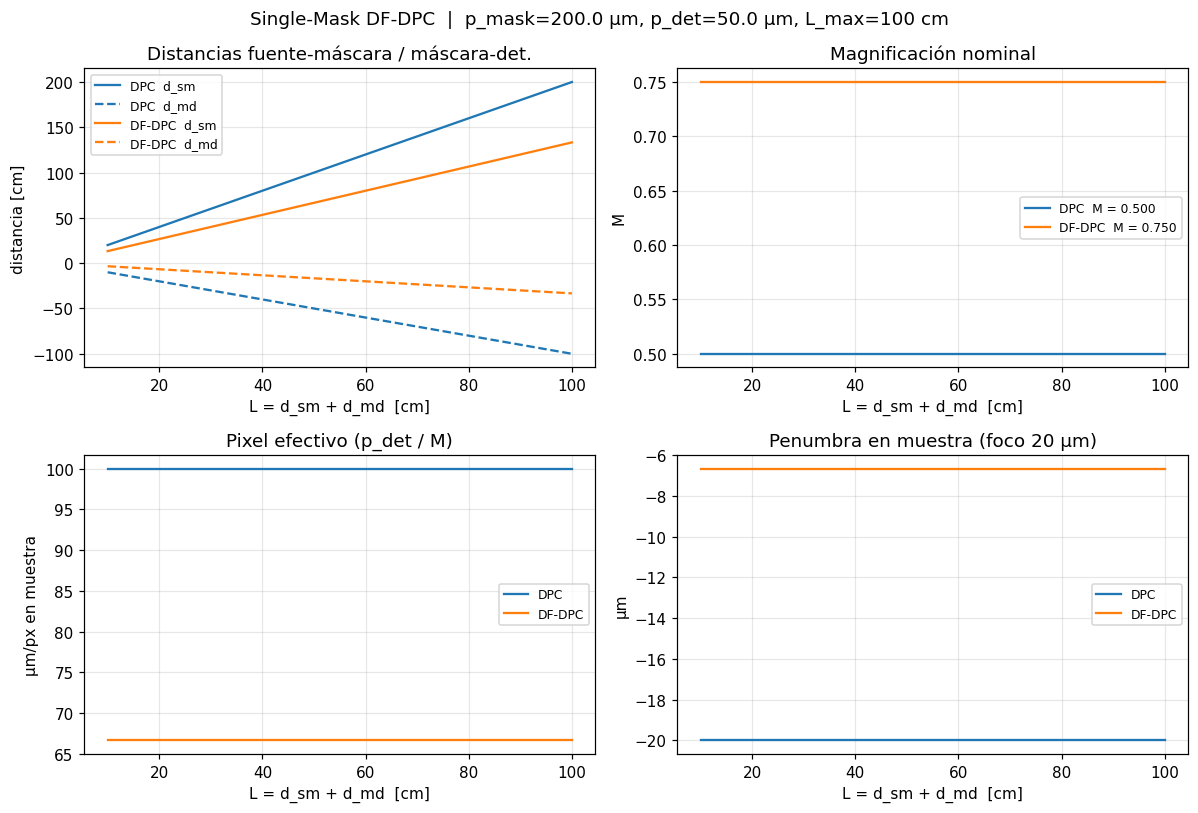

In [40]:
def plot_sweep(lab: LabSetup):
    fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))
    for cfg, color in [('DPC', 'tab:blue'), ('DF-DPC', 'tab:orange')]:
        s = sweep_geometry(lab, cfg, n=200)
        L_cm = s['L']*100
        ax[0,0].plot(L_cm, s['d_sm']*100, color=color, label=f"{cfg}  d_sm")
        ax[0,0].plot(L_cm, s['d_md']*100, color=color, ls='--', label=f"{cfg}  d_md")
        ax[0,1].plot(L_cm, s['M'], color=color, label=f"{cfg}  M = {s['M'][0]:.3f}")
        ax[1,0].plot(L_cm, s['px_eff_um'], color=color, label=cfg)
        ax[1,1].plot(L_cm, s['blur_obj_um'], color=color, label=cfg)
    for a in ax.ravel():
        a.set_xlabel('L = d_sm + d_md  [cm]'); a.grid(alpha=.3); a.legend(fontsize=8)
    ax[0,0].set_ylabel('distancia [cm]'); ax[0,0].set_title('Distancias fuente-máscara / máscara-det.')
    ax[0,1].set_ylabel('M'); ax[0,1].set_title('Magnificación nominal')
    ax[1,0].set_ylabel('µm/px en muestra'); ax[1,0].set_title('Pixel efectivo (p_det / M)')
    ax[1,1].set_ylabel('µm'); ax[1,1].set_title(f"Penumbra en muestra (foco {lab.focal_spot_um:.0f} µm)")
    fig.suptitle(f"Single-Mask DF-DPC  |  p_mask={lab.p_mask_um} µm, p_det={lab.p_det_um} µm, L_max={lab.L_max_m*100:.0f} cm")
    fig.tight_layout()
    return fig

plot_sweep(lab);

## 7. Diagrama de la geometría seleccionada

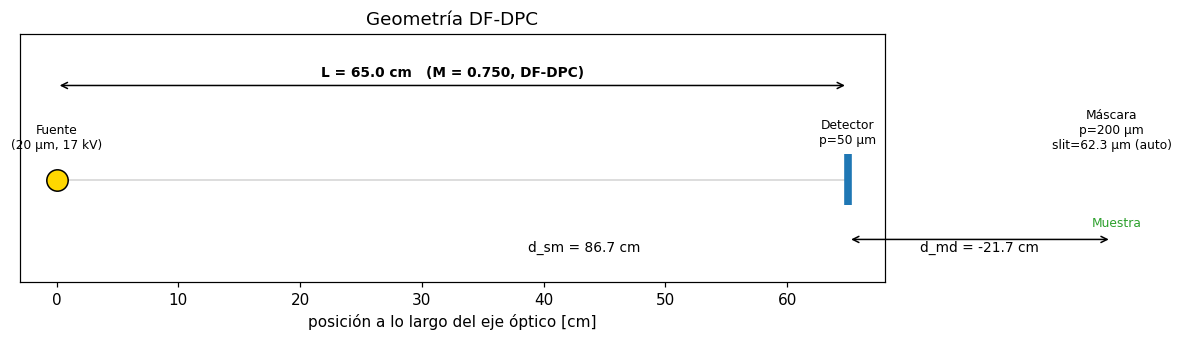

In [41]:
def plot_geometry(lab: LabSetup, L_m: float, config: Optional[str] = None):
    cfg = (config or lab.config).upper()
    M = nominal_magnification(lab, cfg)
    d_sm, d_md = distances_from_L(L_m, M)
    w_um, w_src, _ = resolve_slit(lab, cfg)
    fig, ax = plt.subplots(figsize=(11, 3.2))
    y0 = 0
    ax.hlines(y0, 0, L_m*100, color='lightgray', lw=1)
    ax.plot(0, y0, 'o', color='gold', markersize=14, markeredgecolor='k')
    ax.text(0, y0+0.18, f"Fuente\n({lab.focal_spot_um:.0f} µm, {lab.kV:.0f} kV)", ha='center', fontsize=8)
    xm = d_sm*100
    ax.vlines(xm, y0-0.12, y0+0.12, color='tab:orange', lw=4)
    slit_lbl = f"{w_um:.1f} µm ({w_src})" if not np.isnan(w_um) else 'N/A'
    ax.text(xm, y0+0.18, f"Máscara\np={lab.p_mask_um:.0f} µm\nslit={slit_lbl}", ha='center', fontsize=8)
    ax.vlines(xm+0.4, y0-0.08, y0+0.08, color='tab:green', lw=3)
    ax.text(xm+0.4, y0-0.28, 'Muestra', ha='center', fontsize=8, color='tab:green')
    xd = (d_sm+d_md)*100
    ax.vlines(xd, y0-0.15, y0+0.15, color='tab:blue', lw=5)
    ax.text(xd, y0+0.21, f"Detector\np={lab.p_det_um:.0f} µm", ha='center', fontsize=8)
    ax.annotate('', xy=(xm, y0-0.35), xytext=(0, y0-0.35), arrowprops=dict(arrowstyle='<->'))
    ax.text(xm/2, y0-0.42, f"d_sm = {d_sm*100:.1f} cm", ha='center', fontsize=9)
    ax.annotate('', xy=(xd, y0-0.35), xytext=(xm, y0-0.35), arrowprops=dict(arrowstyle='<->'))
    ax.text((xm+xd)/2, y0-0.42, f"d_md = {d_md*100:.1f} cm", ha='center', fontsize=9)
    ax.annotate('', xy=(xd, y0+0.55), xytext=(0, y0+0.55), arrowprops=dict(arrowstyle='<->'))
    ax.text(xd/2, y0+0.6, f"L = {L_m*100:.1f} cm   (M = {M:.3f}, {cfg})", ha='center', fontsize=9, weight='bold')
    ax.set_ylim(-0.6, 0.85); ax.set_xlim(-3, L_m*100+3)
    ax.set_yticks([]); ax.set_xlabel('posición a lo largo del eje óptico [cm]')
    ax.set_title(f"Geometría {cfg}")
    fig.tight_layout()
    return fig

plot_geometry(lab, L_m=0.65, config='DF-DPC');

## 8. Validación: ¿la condición de Moiré nulo es alcanzable?

In [23]:
def check_feasibility(lab: LabSetup, tol: float = 0.15):
    ok = []
    for cfg, N in _N_BY_CONFIG.items():
        if cfg == 'DF':
            continue
        M = nominal_magnification(lab, cfg)
        deviation = abs(M - N) / N
        status = 'OK' if deviation <= tol else 'REVISAR'
        ok.append((cfg, N, M, deviation, status))
        msg = f"{cfg:7s}  M* = {M:.3f}   target N = {N}   desvío = {deviation*100:5.2f}%   → {status}"
        print(msg)
        if status != 'OK':
            warnings.warn(f"{cfg}: desvío {deviation*100:.1f}% del Moiré nulo — ajustá p_mask o p_det")
    print()
    for cfg, _, M, *_ in ok:
        d_sm_max, d_md_max = distances_from_L(lab.L_max_m, M)
        print(f"{cfg:7s}  con L = L_max = {lab.L_max_m*100:.1f} cm  →  d_sm = {d_sm_max*100:.1f} cm, d_md = {d_md_max*100:.1f} cm")

check_feasibility(lab)

DPC      M* = 0.500   target N = 2   desvío = 75.00%   → REVISAR
DF-DPC   M* = 0.750   target N = 3   desvío = 75.00%   → REVISAR

DPC      con L = L_max = 100.0 cm  →  d_sm = 200.0 cm, d_md = -100.0 cm
DF-DPC   con L = L_max = 100.0 cm  →  d_sm = 133.3 cm, d_md = -33.3 cm


C:\Users\Petya_\AppData\Local\Temp\ipykernel_2072\3499239443.py:13: UserWarning: DPC: desvío 75.0% del Moiré nulo — ajustá p_mask o p_det
  warnings.warn(f"{cfg}: desvío {deviation*100:.1f}% del Moiré nulo — ajustá p_mask o p_det")
C:\Users\Petya_\AppData\Local\Temp\ipykernel_2072\3499239443.py:13: UserWarning: DF-DPC: desvío 75.0% del Moiré nulo — ajustá p_mask o p_det
  warnings.warn(f"{cfg}: desvío {deviation*100:.1f}% del Moiré nulo — ajustá p_mask o p_det")


## 9. Test rápido con tus valores

Editá la celda. Dejá `slit_um=None` para que se compute el slit óptimo.

In [ ]:
# Parámetros del paper (Optica 12, 1895, 2025)
mi_lab = LabSetup(
    # --- Máscara (fabricada, slit fijo) ---
    p_mask_um       = 53.0,    # período nominal de la máscara [µm]
    slit_um         = 20.0,    # ancho de apertura grabado en la máscara [µm]
    au_thickness_um = 100.0,   # espesor de oro [µm]  (~91 % absorción @ 40 keV)
    slit_min_um     = 2.0,     # límite mecánico inferior (referencia)
    slit_max_um     = 40.0,    # límite mecánico superior (referencia)
    slit_safety     = 0.85,
    # --- Detector WidePix ---
    p_det_um   = 55.0,         # pitch de pixel [µm]
    det_w_mm   = 70.0,         # ancho activo [mm]  (5 chips × 256 px × 55 µm)
    det_h_mm   = 14.0,         # alto activo  [mm]
    # --- Fuente Hamamatsu L8121-03 ---
    focal_spot_um = 20.0,      # foco estándar [µm]; el paper usa 7 / 20 / 50 µm
    kV            = 40.0,      # tensión del tubo [kV]
    # --- Restricciones del banco ---
    L_max_m = 2.00,            # DPC necesita ~1.20 m; DF-DPC necesita ~1.80 m
    L_min_m = 0.70,            # mínimo práctico (d_sm ≥ ~23 cm para DF-DPC)
    # --- Adquisición ---
    config   = 'DF-DPC',
    n_dither = 8,
)

# Puntos de operación exactos del paper
L_DPC    = 1.20  # d_sm ≈ 60 cm + d_md ≈ 60 cm
L_DFDPC  = 1.80  # d_sm ≈ 60 cm + d_md ≈ 120 cm

summary_table(mi_lab); print()
check_feasibility(mi_lab); print()
ideal_slit_report(mi_lab)
print("=== Punto de operación DPC (paper) ===")
operating_point(mi_lab, L_m=L_DPC, config='DPC')
print("\n=== Punto de operación DF-DPC (paper) ===")
operating_point(mi_lab, L_m=L_DFDPC, config='DF-DPC')
plot_sweep(mi_lab)
plot_slit_design(mi_lab)
plot_geometry(mi_lab, L_m=L_DFDPC, config='DF-DPC');

## 9b. Espacio de trabajo disponible

Visualización del espacio de parámetros ($d_{sm}$, $d_{md}$) en función del largo total del banco $L$.

- **Líneas de configuración**: cada config (DPC, DF-DPC) es una línea recta $d_{md} = d_{sm}(M-1)$ porque $M$ está fijado por la condición de Moiré.
- **Región válida** (franja gris): acotada por $L_{min} \le d_{sm}+d_{md} \le L_{max}$.
- **Estrellas**: puntos de operación del paper ($d_{sm} \approx 60$ cm en ambas configs).

In [ ]:
def plot_workspace(lab: LabSetup,
                   paper_points: dict = None):
    """
    paper_points: {'DPC': L_m, 'DF-DPC': L_m}  – puntos del paper a marcar con estrella.
    """
    if paper_points is None:
        paper_points = {}

    CONFIGS = [('DPC', 2), ('DF-DPC', 3)]
    colors  = {'DPC': 'tab:blue', 'DF-DPC': 'tab:orange'}

    # ── derivados ──────────────────────────────────────────────────────────
    Ms = {cfg: N * lab.p_det_um / lab.p_mask_um for cfg, N in CONFIGS}

    fig = plt.figure(figsize=(14, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32)
    ax_plane = fig.add_subplot(gs[0, :])   # panel ancho: plano (d_sm, d_md)
    ax_L     = fig.add_subplot(gs[1, 0])   # d_sm y d_md vs L
    ax_qual  = fig.add_subplot(gs[1, 1])   # FOV y resolución vs M (comparación configs)

    # ── Panel A: plano d_sm – d_md ─────────────────────────────────────────
    d_sm_max_plot = lab.L_max_m / min(Ms.values()) * 1.05
    d_sm_r = np.linspace(0.01, d_sm_max_plot, 500)

    # franja L_min ≤ d_sm + d_md ≤ L_max
    ax_plane.fill_between(
        d_sm_r * 100,
        np.maximum(0, lab.L_min_m - d_sm_r) * 100,
        np.maximum(0, lab.L_max_m - d_sm_r) * 100,
        color='gray', alpha=0.12, label=f'banco válido [{lab.L_min_m*100:.0f}–{lab.L_max_m*100:.0f} cm]',
    )
    # líneas L = cte
    for L_iso in np.arange(0.5, lab.L_max_m + 0.01, 0.25):
        dsm_pts = np.array([0, L_iso])
        dmd_pts = np.array([L_iso, 0])
        ax_plane.plot(dsm_pts * 100, dmd_pts * 100, color='gray', lw=0.5, alpha=0.4)
        ax_plane.text(L_iso * 100 * 0.08, L_iso * 100 * 0.92,
                      f'{L_iso*100:.0f}', fontsize=6, color='gray', ha='center')

    for cfg, N in CONFIGS:
        M = Ms[cfg]
        d_md_line = d_sm_r * (M - 1)
        mask_valid = (d_sm_r + d_md_line >= lab.L_min_m) & (d_sm_r + d_md_line <= lab.L_max_m)
        ax_plane.plot(d_sm_r * 100, d_md_line * 100, color=colors[cfg], lw=2.5,
                      label=f'{cfg}  M={M:.3f}')
        # segmento dentro del banco resaltado
        if mask_valid.any():
            ax_plane.plot(d_sm_r[mask_valid] * 100, d_md_line[mask_valid] * 100,
                          color=colors[cfg], lw=5, alpha=0.35)
        # estrella del paper
        if cfg in paper_points:
            L_p = paper_points[cfg]
            dsm_p = L_p / M
            dmd_p = L_p - dsm_p
            ax_plane.plot(dsm_p * 100, dmd_p * 100, '*', color=colors[cfg],
                          ms=18, zorder=5,
                          label=f'{cfg} paper: d_sm={dsm_p*100:.0f} cm, d_md={dmd_p*100:.0f} cm')
            ax_plane.annotate(
                f'{cfg}\n$d_{{sm}}$={dsm_p*100:.0f} cm\n$d_{{md}}$={dmd_p*100:.0f} cm',
                xy=(dsm_p * 100, dmd_p * 100), xytext=(dsm_p * 100 + 4, dmd_p * 100 + 4),
                fontsize=8, color=colors[cfg],
                arrowprops=dict(arrowstyle='->', color=colors[cfg], lw=1.2),
            )

    ax_plane.set_xlabel('$d_{sm}$ — distancia fuente–máscara [cm]', fontsize=10)
    ax_plane.set_ylabel('$d_{md}$ — distancia máscara–detector [cm]', fontsize=10)
    ax_plane.set_title('Espacio de trabajo: plano ($d_{sm}$, $d_{md}$)', fontsize=11)
    ax_plane.set_xlim(0, d_sm_max_plot * 100)
    ax_plane.set_ylim(0, lab.L_max_m * 100 * 1.02)
    ax_plane.legend(fontsize=8, loc='upper left')
    ax_plane.grid(alpha=0.25)
    ax_plane.set_aspect('equal')

    # ── Panel B: d_sm y d_md vs L ──────────────────────────────────────────
    L_range = np.linspace(lab.L_min_m, lab.L_max_m, 300)
    for cfg, N in CONFIGS:
        M = Ms[cfg]
        d_sm = L_range / M
        d_md = L_range - d_sm
        ax_L.plot(L_range * 100, d_sm * 100, color=colors[cfg], lw=1.8,
                  label=f'{cfg} $d_{{sm}}$')
        ax_L.plot(L_range * 100, d_md * 100, color=colors[cfg], lw=1.8, ls='--',
                  label=f'{cfg} $d_{{md}}$')
        if cfg in paper_points:
            L_p = paper_points[cfg]
            ax_L.axvline(L_p * 100, color=colors[cfg], lw=1.2, ls=':')
            ax_L.plot(L_p * 100, L_p / M * 100, '*', color=colors[cfg], ms=12, zorder=5)
            ax_L.plot(L_p * 100, (L_p - L_p / M) * 100, '*', color=colors[cfg], ms=12, zorder=5)

    ax_L.set_xlabel('L = $d_{sm}+d_{md}$ [cm]')
    ax_L.set_ylabel('Distancia [cm]')
    ax_L.set_title('Distancias vs longitud total L')
    ax_L.legend(fontsize=7, ncol=2)
    ax_L.grid(alpha=0.3)

    # ── Panel C: calidad (FOV, px_eff, blur) por config ────────────────────
    cfg_labels, fovs_w, fovs_h, pxs, blurs = [], [], [], [], []
    for cfg, N in CONFIGS:
        M = Ms[cfg]
        cfg_labels.append(cfg)
        fovs_w.append(lab.det_w_mm / M)
        fovs_h.append(lab.det_h_mm / M)
        pxs.append(lab.p_det_um / M)
        blurs.append(lab.focal_spot_um * (M - 1) / M)   # penumbra en muestra [µm]

    x = np.arange(len(cfg_labels))
    w = 0.25
    b1 = ax_qual.bar(x - w,   fovs_w,  w, label='FOV-ancho [mm]',      color='steelblue')
    b2 = ax_qual.bar(x,       fovs_h,  w, label='FOV-alto [mm]',       color='skyblue')
    b3 = ax_qual.bar(x + w,   pxs,     w, label='px efectivo [µm]',    color='tomato')
    ax_qual.bar_label(b1, fmt='%.1f', fontsize=8, padding=2)
    ax_qual.bar_label(b2, fmt='%.1f', fontsize=8, padding=2)
    ax_qual.bar_label(b3, fmt='%.1f', fontsize=8, padding=2)
    ax_qual.set_xticks(x); ax_qual.set_xticklabels(cfg_labels)
    ax_qual.set_ylabel('mm  /  µm')
    ax_qual.set_title(f'FOV y resolución (foco={lab.focal_spot_um:.0f} µm)')
    ax_qual.legend(fontsize=8)
    ax_qual.grid(axis='y', alpha=0.3)

    fig.suptitle(
        f'Espacio de trabajo  |  $p_{{mask}}$={lab.p_mask_um:.0f} µm, '
        f'$p_{{det}}$={lab.p_det_um:.0f} µm, slit={lab.slit_um:.0f} µm, '
        f'foco={lab.focal_spot_um:.0f} µm',
        fontsize=12, fontweight='bold',
    )
    plt.savefig('workspace.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figura guardada en workspace.png")

plot_workspace(
    mi_lab,
    paper_points={'DPC': L_DPC, 'DF-DPC': L_DFDPC},
)

### Stress test: foco grande
Con foco de 50 µm la penumbra ya cubre un pixel en DF-DPC → ningún slit válido. El sistema debe emitir warnings.

In [25]:
stress = LabSetup(focal_spot_um=50.0, config='DF-DPC', slit_um=None)
ideal_slit_report(stress)

Foco fuente : 50.0 µm
p_mask      : 200.0 µm   p_det : 50.0 µm
slit bounds : [2.0, 50.0] µm   safety=0.85

--- DPC  (M=0.500) ---
  w_max (teórico) : 150.00 µm   (beamlet = 1 px)
  w_opt recomend. :  50.00 µm   (× safety 0.85)
  zona iluminada en detector:  0.00 µm (geom 25.00 + penumbra -25.00)
  duty cycle (w/p_mask) : 0.250
  [INFO] w_opt teórico (127.5 µm) excede límite mecánico/duty (50.0 µm); recortado.

--- DF-DPC  (M=0.750) ---
  w_max (teórico) :  83.33 µm   (beamlet = 1 px)
  w_opt recomend. :  50.00 µm   (× safety 0.85)
  zona iluminada en detector: 25.00 µm (geom 37.50 + penumbra -12.50)
  duty cycle (w/p_mask) : 0.250
  [INFO] w_opt teórico (70.8 µm) excede límite mecánico/duty (50.0 µm); recortado.



C:\Users\Petya_\AppData\Local\Temp\ipykernel_2072\1001748415.py:63: UserWarning: [INFO] w_opt teórico (127.5 µm) excede límite mecánico/duty (50.0 µm); recortado.
  warnings.warn(w)
C:\Users\Petya_\AppData\Local\Temp\ipykernel_2072\1001748415.py:63: UserWarning: [INFO] w_opt teórico (70.8 µm) excede límite mecánico/duty (50.0 µm); recortado.
  warnings.warn(w)


## 10. Explorador interactivo: slit → distancias válidas

Usá el slider de **slit** para fijar el ancho de apertura. La calculadora te devuelve, para cada configuración (DPC / DF-DPC):

- Si ese slit es **válido** con la magnificación fija por la condición de Moiré ($M = N\,p_d/p_m$).
- El **rango de distancias** $d_{sm}$ y $d_{md}$ alcanzable dentro de los límites del banco ($L_{min}$–$L_{max}$).
- Un segundo slider de **L** para ver el punto de operación exacto.

> **Por qué M no cambia con L**: la condición de Moiré fija $M^\star = N\,p_d/p_m$. Luego $d_{sm} = L/M^\star$ y $d_{md} = L(M^\star-1)/M^\star$ escalan con $L$, pero $M^\star$ permanece constante.  El slit sólo determina si el beamlet cabe en 1 pixel para ese $M^\star$.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def slit_explorer(lab: LabSetup):
    CONFIGS = [('DPC', 2), ('DF-DPC', 3)]

    slit_slider = widgets.FloatSlider(
        value=(lab.slit_min_um + lab.slit_max_um) / 2,
        min=lab.slit_min_um, max=lab.slit_max_um, step=0.5,
        description='Slit w [µm]:', continuous_update=True,
        layout=widgets.Layout(width='600px'),
        style={'description_width': '90px'},
    )
    L_slider = widgets.FloatSlider(
        value=(lab.L_min_m + lab.L_max_m) / 2 * 100,
        min=lab.L_min_m * 100, max=lab.L_max_m * 100, step=0.5,
        description='L [cm]:', continuous_update=True,
        layout=widgets.Layout(width='600px'),
        style={'description_width': '90px'},
    )

    out = widgets.Output()

    def update(w_um, L_cm):
        L_m = L_cm / 100
        fs, pd, pm = lab.focal_spot_um, lab.p_det_um, lab.p_mask_um
        M_max_slit = (pd + fs) / (w_um + fs)

        with out:
            clear_output(wait=True)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
            colors = {'DPC': 'tab:blue', 'DF-DPC': 'tab:orange'}
            w_range = np.linspace(max(0.2, lab.slit_min_um * 0.4), lab.slit_max_um * 1.05, 300)

            # Plot 1 – beamlet en detector vs slit
            for cfg, N in CONFIGS:
                M = N * pd / pm
                beamlet = w_range * M + fs * (M - 1)
                ax1.plot(w_range, beamlet, color=colors[cfg], lw=1.8, label=f'{cfg}  M={M:.3f}')
                w_max_cfg = (pd - fs * (M - 1)) / M
                if 0 < w_max_cfg <= lab.slit_max_um * 1.1:
                    ax1.axvline(w_max_cfg, color=colors[cfg], ls=':', lw=1.2, alpha=0.8,
                                label=f'w_max {cfg} = {w_max_cfg:.1f} µm')

            ax1.axhline(pd, color='red', ls='--', lw=1.4, label=f'p_det = {pd:.0f} µm')
            ax1.axvline(w_um, color='black', lw=2, label=f'slit actual = {w_um:.1f} µm')
            ax1.axvspan(lab.slit_min_um, lab.slit_max_um, color='gray', alpha=0.07,
                        label=f'rango mecánico [{lab.slit_min_um:.0f},{lab.slit_max_um:.0f}] µm')
            ax1.set_xlabel('Ancho de slit  w  [µm]')
            ax1.set_ylabel('Beamlet en detector  [µm]')
            ax1.set_title('Restricción: beamlet ≤ 1 pixel')
            ax1.set_ylim(bottom=0)
            ax1.legend(fontsize=7)
            ax1.grid(alpha=0.3)

            # Plot 2 – d_sm y d_md vs L
            L_range = np.linspace(lab.L_min_m, lab.L_max_m, 200)
            for cfg, N in CONFIGS:
                M = N * pd / pm
                illum = w_um * M + fs * (M - 1)
                valid = illum <= pd
                alpha = 1.0 if valid else 0.25
                d_sm_r = L_range / M
                d_md_r = L_range - d_sm_r
                lbl = '✓' if valid else '✗'
                ax2.plot(L_range * 100, d_sm_r * 100, color=colors[cfg], alpha=alpha, lw=1.8,
                         label=f'{lbl} {cfg}  d_sm')
                ax2.plot(L_range * 100, d_md_r * 100, color=colors[cfg], alpha=alpha, lw=1.8,
                         ls='--', label=f'{lbl} {cfg}  d_md')

            ax2.axvline(L_cm, color='black', lw=1.5, ls=':', label=f'L = {L_cm:.1f} cm')
            ax2.set_xlabel('L = d_sm + d_md  [cm]')
            ax2.set_ylabel('Distancia  [cm]')
            ax2.set_title('Distancias d_sm / d_md  vs  L')
            ax2.legend(fontsize=7)
            ax2.grid(alpha=0.3)

            fig.suptitle(
                f'Slit = {w_um:.1f} µm  |  M_max (beamlet ≤ 1 px) = {M_max_slit:.3f}',
                fontweight='bold',
            )
            fig.tight_layout()
            display(fig)   # display() en lugar de plt.show() para VS Code
            plt.close(fig)

            # ── Tabla resumen ────────────────────────────────────────────────
            print(f"{'─'*62}")
            print(f"  slit  = {w_um:.1f} µm     L = {L_cm:.1f} cm")
            print(f"  foco  = {fs:.0f} µm        M_max (slit) = {M_max_slit:.4f}")
            print(f"{'─'*62}")
            for cfg, N in CONFIGS:
                M = N * pd / pm
                illum = w_um * M + fs * (M - 1)
                valid = illum <= pd
                mark = '✓ VÁLIDO  ' if valid else '✗ INVÁLIDO'
                d_sm_pt = L_m / M
                d_md_pt = L_m - d_sm_pt
                d_sm_min, d_sm_max = lab.L_min_m / M, lab.L_max_m / M
                d_md_min, d_md_max = lab.L_min_m * (M - 1) / M, lab.L_max_m * (M - 1) / M
                w_max_cfg = (pd - fs * (M - 1)) / M
                print(f"\n  [{mark}]  {cfg}  (N={N}, M* = {M:.4f})")
                print(f"    Beamlet en detector  : {illum:.2f} µm  (límite: {pd:.1f} µm)")
                print(f"    Slit máx para {cfg:6s}: {max(w_max_cfg, 0):.2f} µm")
                if valid:
                    print(f"    @ L = {L_cm:.1f} cm  →  d_sm = {d_sm_pt*100:.2f} cm,  d_md = {d_md_pt*100:.2f} cm")
                    print(f"    Rango d_sm : [{d_sm_min*100:.1f}, {d_sm_max*100:.1f}] cm")
                    print(f"    Rango d_md : [{d_md_min*100:.1f}, {d_md_max*100:.1f}] cm")
                else:
                    print(f"    → Reducí el slit por debajo de {max(w_max_cfg, 0):.1f} µm para usar {cfg}.")
            print(f"\n{'─'*62}")

    interactive_out = widgets.interactive_output(update, {'w_um': slit_slider, 'L_cm': L_slider})
    display(widgets.VBox([slit_slider, L_slider]), interactive_out)

slit_explorer(mi_lab)